# Bài tập 2: Khảo sát đánh đổi Thời gian – Tần số

So sánh trực quan **Wideband Spectrogram** và **Narrowband Spectrogram** trên cùng một tín hiệu tiếng nói. Bài tập giúp thấy rằng cửa sổ ngắn mô tả thời điểm thay đổi tốt hơn, còn cửa sổ dài phân tách các thành phần tần số rõ hơn.

```text
Speech waveform → STFT cửa sổ 5 ms  → Wideband Spectrogram
                → STFT cửa sổ 50 ms → Narrowband Spectrogram
```

**Mục tiêu quan sát:** formant, harmonic, xung mở dây thanh và phụ âm bật.

## 1. Ý tưởng chính

Không thể đồng thời có độ phân giải thời gian và tần số tốt nhất. Wideband dùng cửa sổ ngắn nên bám sát biến đổi nhanh; Narrowband dùng cửa sổ dài nên tách các harmonic rõ hơn. Phần này tập trung vào hình ảnh, không đi sâu vào chứng minh toán học.

## 2. Chuẩn bị môi trường

In [1]:
# Nếu môi trường chưa có package, bỏ dấu # và chạy dòng sau một lần.
# %pip install numpy matplotlib librosa soundfile

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import librosa

plt.style.use("seaborn-v0_8-whitegrid")
AUDIO_CANDIDATES = [
    Path("audio/speech.wav"),
    Path.cwd() / "Wideband và Narrowband Spectrogram" / "audio" / "speech.wav",
    Path("/home/shin-bkb/code/AIO_homework/Wideband và Narrowband Spectrogram/audio/speech.wav"),
]
AUDIO_PATH = next(
    (path for path in AUDIO_CANDIDATES if path.exists()),
    AUDIO_CANDIDATES[-1],
)
print(f"Audio path: {AUDIO_PATH}")

Audio path: audio/speech.wav


## 3. Đọc và quan sát audio

Nên dùng một câu nói dài khoảng 2–10 giây, có nguyên âm kéo dài và một vài phụ âm bật như /p/, /t/, /k/. File được chuẩn hóa về mono, 16 kHz khi đọc.

/home/shin-bkb/code/AIO_homework/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample rate : 16000 Hz
Samples     : 61440
Duration    : 3.84 s


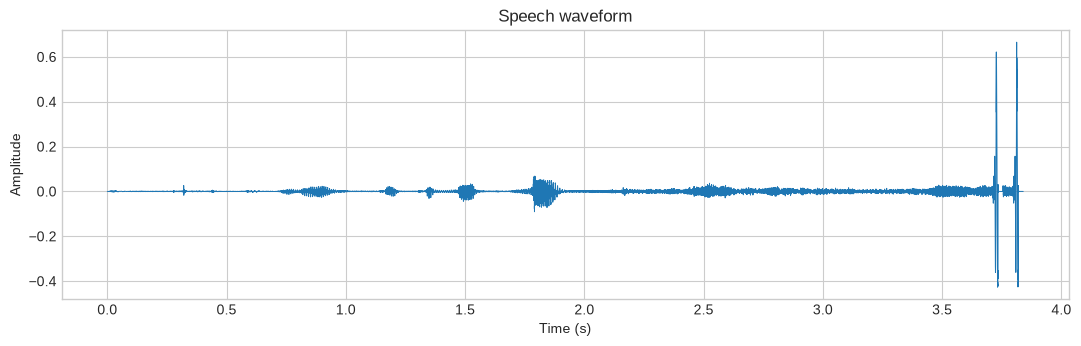

In [3]:
if not AUDIO_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file: {AUDIO_PATH}\n"
        "Hãy đặt file tiếng nói tại audio/speech.wav hoặc đổi AUDIO_PATH."
    )

speech_signal, speech_sr = librosa.load(AUDIO_PATH, sr=16000, mono=True)
speech_signal = speech_signal.astype(np.float64)
speech_duration = len(speech_signal) / speech_sr
speech_time = np.arange(len(speech_signal)) / speech_sr

print(f"Sample rate : {speech_sr} Hz")
print(f"Samples     : {len(speech_signal)}")
print(f"Duration    : {speech_duration:.2f} s")

plt.figure(figsize=(13, 3.5))
plt.plot(speech_time, speech_signal, linewidth=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Speech waveform")
plt.show()
display(Audio(speech_signal, rate=speech_sr))

## 4. Chuyển millisecond sang số sample

Với sample rate 16 kHz, cửa sổ 5 ms tương ứng 80 sample và cửa sổ 50 ms tương ứng 800 sample.

In [4]:
# ============================================================
# TODO 1: Chuyển độ dài cửa sổ từ millisecond sang số sample.
# ============================================================


def milliseconds_to_samples(milliseconds, sr):
    """Convert a window duration in milliseconds to an integer sample count."""
    if milliseconds <= 0 or sr <= 0:
        raise ValueError("milliseconds và sr phải lớn hơn 0.")
    return max(1, int(round(milliseconds * sr / 1000.0)))


wideband_win_length = milliseconds_to_samples(5, speech_sr)
narrowband_win_length = milliseconds_to_samples(50, speech_sr)
print("Wideband window :", wideband_win_length, "samples")
print("Narrowband window:", narrowband_win_length, "samples")

Wideband window : 80 samples
Narrowband window: 800 samples


## 5. STFT và Spectrogram

Hai hàm đầu cung cấp pipeline STFT đã học ở bài 1. Bài tập này thay đổi độ dài cửa sổ để khảo sát hình ảnh thu được.

In [5]:
def framing(signal, frame_length, hop_length):
    if len(signal) < frame_length:
        return np.empty((0, frame_length), dtype=signal.dtype)
    num_frames = 1 + (len(signal) - frame_length) // hop_length
    frames = np.empty((num_frames, frame_length), dtype=signal.dtype)
    for frame_index in range(num_frames):
        start = frame_index * hop_length
        frames[frame_index] = signal[start:start + frame_length]
    return frames


def my_stft(signal, n_fft, hop_length, win_length):
    frames = framing(signal, win_length, hop_length)
    window = np.hanning(win_length)
    windowed_frames = frames * window[np.newaxis, :]
    return np.fft.rfft(windowed_frames, n=n_fft, axis=1).T

In [6]:
# ============================================================
# TODO 2: Sinh Power Spectrogram dB bằng STFT tự cài đặt.
# ============================================================


def extract_db_spectrogram(signal, sr, win_length, hop_length):
    """Return dB power spectrogram, frequency axis and time axis."""
    if signal.ndim != 1:
        raise ValueError("signal phải là mảng 1D.")
    if win_length <= 0 or hop_length <= 0:
        raise ValueError("win_length và hop_length phải lớn hơn 0.")

    n_fft = 1 << (win_length - 1).bit_length()
    stft_matrix = my_stft(
        signal,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
    )
    power = np.maximum(np.abs(stft_matrix) ** 2, 1e-12)
    spectrogram_db = 10.0 * np.log10(power)
    spectrogram_db -= spectrogram_db.max()

    frequencies = np.fft.rfftfreq(n_fft, d=1.0 / sr)
    times = (
        np.arange(spectrogram_db.shape[1]) * hop_length
        + win_length / 2
    ) / sr
    return spectrogram_db, frequencies, times

## 6. Wideband 5 ms và Narrowband 50 ms

Wideband dùng hop 2.5 ms; Narrowband dùng hop 10 ms. Cả hai được hiển thị đến 5 kHz để tập trung vào vùng quan trọng của tiếng nói.

In [7]:
wideband_hop_length = milliseconds_to_samples(2.5, speech_sr)
narrowband_hop_length = milliseconds_to_samples(10, speech_sr)

wideband_db, wideband_frequencies, wideband_times = extract_db_spectrogram(
    speech_signal, speech_sr, wideband_win_length, wideband_hop_length
)
narrowband_db, narrowband_frequencies, narrowband_times = extract_db_spectrogram(
    speech_signal, speech_sr, narrowband_win_length, narrowband_hop_length
)

print("Wideband shape :", wideband_db.shape)
print("Narrowband shape:", narrowband_db.shape)

Wideband shape : (65, 1535)
Narrowband shape: (513, 380)


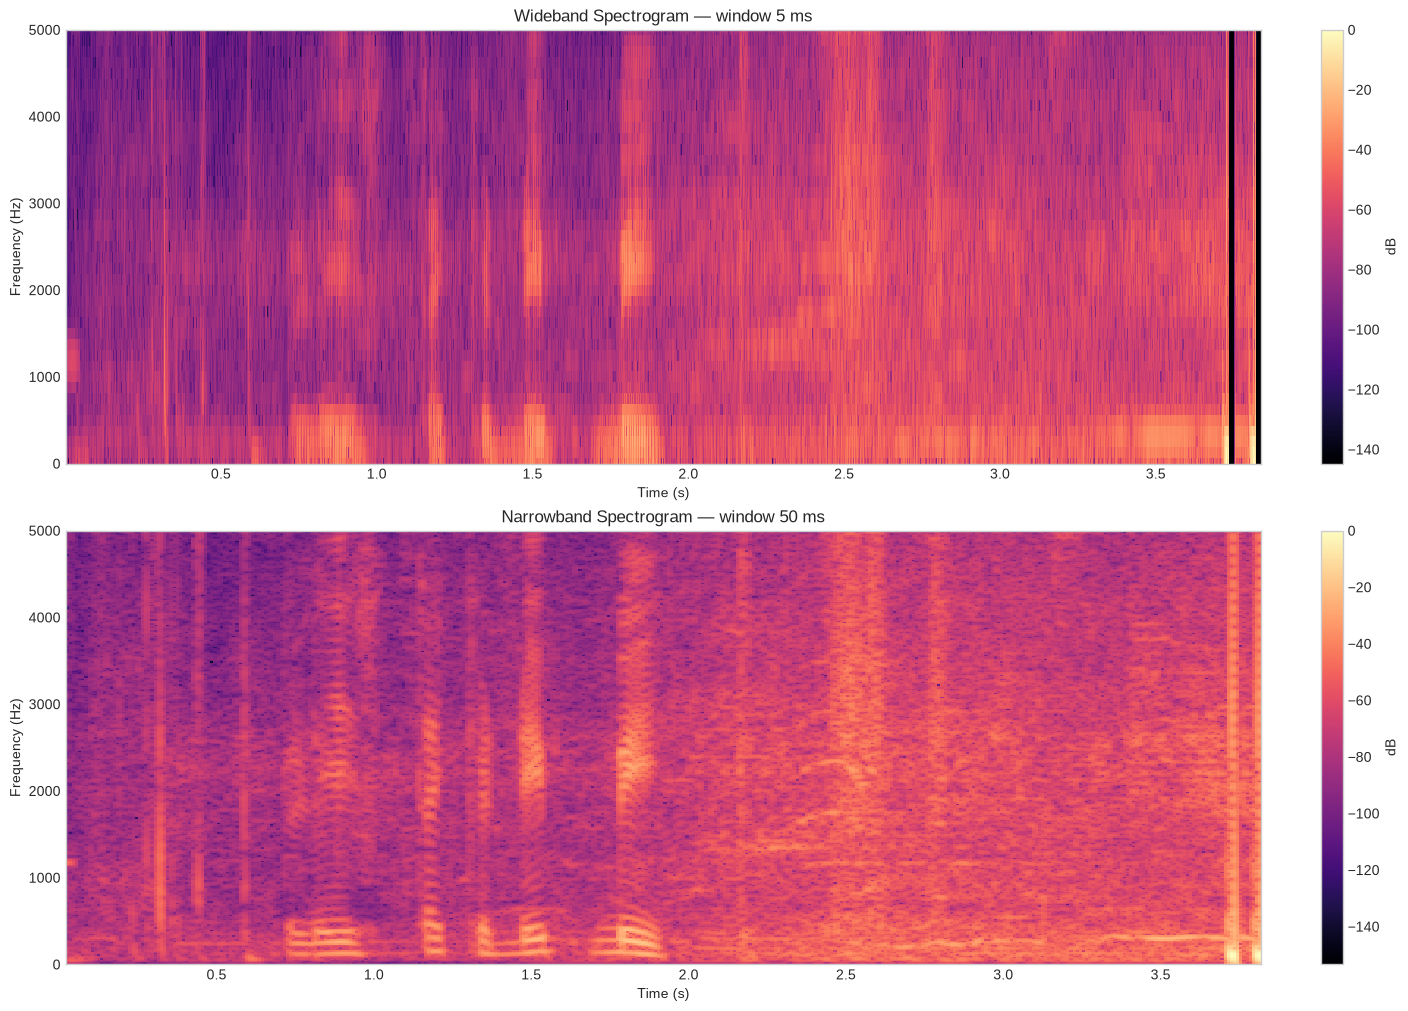

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

wideband_image = axes[0].pcolormesh(
    wideband_times, wideband_frequencies, wideband_db, shading="auto", cmap="magma"
)
axes[0].set(title="Wideband Spectrogram — window 5 ms", xlabel="Time (s)", ylabel="Frequency (Hz)", ylim=(0, 5000))
fig.colorbar(wideband_image, ax=axes[0], label="dB")

narrowband_image = axes[1].pcolormesh(
    narrowband_times, narrowband_frequencies, narrowband_db, shading="auto", cmap="magma"
)
axes[1].set(title="Narrowband Spectrogram — window 50 ms", xlabel="Time (s)", ylabel="Frequency (Hz)", ylim=(0, 5000))
fig.colorbar(narrowband_image, ax=axes[1], label="dB")
plt.show()

## 7. Hướng dẫn đọc hình ảnh

- **Formant $F_1, F_2$:** tìm các dải năng lượng đậm chạy gần như ngang, đặc biệt trong vùng nguyên âm. Wideband thường giúp nhìn đường bao formant rõ hơn.
- **Harmonic $f_0, 2f_0, ...$:** tìm các đường ngang mảnh, song song và cách đều trong Narrowband Spectrogram.
- **Xung mở dây thanh:** tìm các vệt dọc lặp lại trong vùng hữu thanh của Wideband Spectrogram.
- **Phụ âm bật:** tìm một vệt dọc ngắn, năng lượng trải trên dải tần rộng; Wideband định vị thời điểm này rõ hơn.

| Biểu diễn | Điểm mạnh dễ thấy | Hạn chế |
|---|---|---|
| Wideband, 5 ms | Thời điểm thay đổi, xung thanh hầu, burst | Harmonic dễ hòa vào nhau |
| Narrowband, 50 ms | Các harmonic song song, cấu trúc tần số | Biến đổi nhanh bị kéo dài theo thời gian |

## 8. Thử nghiệm thêm

Thay `speech.wav` bằng bản ghi có nguyên âm kéo dài rồi một phụ âm bật, ví dụ kéo dài âm **a** trước khi nói một từ bắt đầu bằng **t** hoặc **k**. Thử thêm cửa sổ 10 ms, 25 ms và 100 ms để quan sát sự chuyển đổi dần giữa hai kiểu spectrogram.

## 9. Kết luận

Không có một cửa sổ STFT nào đồng thời tối ưu cả độ phân giải thời gian và độ phân giải tần số. Cửa sổ ngắn 5 ms tạo ra Wideband Spectrogram, giúp xác định chính xác thời điểm xuất hiện của xung mở dây thanh, onset và phụ âm bật. Đổi lại, các harmonic có thể bị hòa vào nhau vì độ phân giải tần số thấp.

Cửa sổ dài 50 ms tạo ra Narrowband Spectrogram, cho phép quan sát các harmonic và cấu trúc tần số ổn định rõ hơn. Tuy nhiên, các biến đổi nhanh bị trải rộng theo thời gian, nên vị trí chính xác của burst hoặc onset kém rõ hơn.

Vì vậy, Wideband phù hợp khi cần phân tích biến đổi theo thời gian và cấu trúc formant, còn Narrowband phù hợp khi cần quan sát pitch và harmonic. Việc lựa chọn cửa sổ phải dựa trên mục tiêu phân tích thay vì xem một biểu diễn là tốt hơn tuyệt đối.